# Пайплайн для задачи классификации

In [ ]:
import pandas as pd
import numpy as np
import warnings
import re
import logging
from typing import Tuple, List
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    handlers=[
        logging.FileHandler("data_processing.log"),
        logging.StreamHandler(),
    ],
    datefmt="%Y-%m-%d %H:%M:%S",
    force=True,
)

logger = logging.getLogger(__name__)

warnings.filterwarnings("ignore")


In [23]:
class DataHandler:
    """Базовый абстрактный класс обработчика данных в паттерне
    "Цепочка ответственности".
    """

    def __init__(self) -> None:
        """Инициализирует обработчик данных."""
        self._next_handler = None
        self.logger = logging.getLogger(self.__class__.__name__)

    def set_next(self, handler: "DataHandler") -> "DataHandler":
        """Устанавливает следующий обработчик в цепочке.

        Аргументы:
            handler: Следующий обработчик в цепочке.

        Вернет:
            Установленный обработчик для цепочного вызова.
        """
        self._next_handler = handler
        return handler

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Обрабатывает DataFrame и передает следующему обработчику.

        Аргументы:
            df: Входной DataFrame для обработки.

        Вернет:
            Обработанный DataFrame.
        """
        if self._next_handler:
            return self._next_handler.handle(df)
        return df


class SexExtractor(DataHandler):
    """Извлекает пол кандидата из текстового поля."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель пола.

        Аргументы:
            source_column: Название столбца с информацией о поле и возрасте.
        """
        super().__init__()
        self.source_column = source_column
        self._sex_pattern = r"(мужчина|male|женщина|female)"

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Извлекает информацию о поле из текста.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'sex'.
        """
        self.logger.info(f"Извлечение пола из столбца {self.source_column}")
        df = df.copy()
        df["sex"] = None
        extracted_count = 0

        for i, text in enumerate(df[self.source_column]):
            text = str(text)
            sex_match = re.search(self._sex_pattern, text, re.IGNORECASE)
            if sex_match:
                sex = sex_match.group(1).lower()
                if "муж" in sex or "male" in sex:
                    df.at[i, "sex"] = "M"
                    extracted_count += 1
                elif "жен" in sex or "female" in sex:
                    df.at[i, "sex"] = "Ж"
                    extracted_count += 1

        self.logger.info(f"Извлечено {extracted_count} значений пола")
        return super().handle(df)


class AgeExtractor(DataHandler):
    """Извлекает возраст из текстового поля."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель возраста.

        Аргументы:
            source_column: Название столбца с информацией о поле и возрасте.
        """
        super().__init__()
        self.source_column = source_column
        self._age_pattern = r"(\d+)\s+(?:лет|год|года|years?)"

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Извлекает возраст из текста с помощью регулярных выражений.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'age'.
        """
        self.logger.info(f"Извлечение возраста из столбца {self.source_column}")
        df = df.copy()
        df["age"] = None
        extracted_count = 0

        for i, text in enumerate(df[self.source_column]):
            text = str(text)
            age_match = re.search(self._age_pattern, text, re.IGNORECASE)
            if age_match:
                try:
                    age = int(age_match.group(1))
                    # Фильтрация некорректных значений возраста
                    if 18 <= age <= 70:  # Реалистичный диапазон возраста для работы
                        df.at[i, "age"] = age
                        extracted_count += 1
                except ValueError:
                    self.logger.warning(
                        f"Не удалось преобразовать возраст: {age_match.group(1)}"
                    )
                    continue

        df["age"] = pd.to_numeric(df["age"], errors="coerce")
        self.logger.info(f"Извлечено {extracted_count} значений возраста")
        self.logger.info(f"Средний возраст: {df['age'].mean():.1f}")
        return super().handle(df)


class SalaryExtractor(DataHandler):
    """Извлекает и конвертирует зарплату в российские рубли."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель зарплаты.

        Аргументы:
            source_column: Название столбца с информацией о зарплате.
        """
        super().__init__()
        self.source_column = source_column
        self._exchange_rates = {
            "RUB": 1,
            "USD": 63.9966,
            "EUR": 71.1194,
            "KZT": 0.1645,
            "UZS": 0.0068,
            "UAH": 2.5415,
            "BYN": 31.2927,
            "AZN": 37.7227,
            "KGS": 0.9147,
        }

        self._currency_patterns = {
            "RUB": r"(RUB|руб|rph|₽|RUR|РУБ)",
            "USD": r"(USD|\$|долл|usd)",
            "EUR": r"(EUR|€|евро|eur)",
            "KZT": r"(KZT|тенге|kzt)",
            "KGS": r"(KGS|сом|kgs)",
            "UAH": r"(UAH|грив|uah)",
            "BYN": r"(BYN|бел|byn)",
            "AZN": r"(AZN|манат|azn)",
            "UZS": r"(UZS|uzs|сум|som|cym)",
        }

        self._num_pattern = r"([\d\s]+)"

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Извлекает зарплату и конвертирует в рубли.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'salary' в рублях.
        """
        self.logger.info(f"Извлечение зарплаты из столбца {self.source_column}")
        df = df.copy()
        df["salary"] = None
        extracted_count = 0
        conversion_stats = {currency: 0 for currency in self._exchange_rates}

        for i, text in enumerate(df[self.source_column]):
            text = str(text).strip()
            num_salary = 0

            # Извлечение числового значения
            cleaned_text = re.sub(r"[^0-9,.\-]", "", text).replace(",", ".")
            num_match = re.search(self._num_pattern, cleaned_text)

            if num_match:
                try:
                    num_salary = float(num_match.group(1).replace(" ", ""))
                except (ValueError, AttributeError):
                    self.logger.debug(
                        f"Не удалось преобразовать число в тексте: {text}"
                    )

            # Конвертация в рубли
            text = text.upper()
            for currency, pattern in self._currency_patterns.items():
                if re.search(pattern, text, re.IGNORECASE):
                    num_salary *= self._exchange_rates[currency]
                    conversion_stats[currency] += 1
                    break

            if num_salary > 0:
                df.at[i, "salary"] = num_salary
                extracted_count += 1

        self.logger.info(f"Извлечено {extracted_count} значений зарплаты")
        for currency, count in conversion_stats.items():
            if count > 0:
                self.logger.debug(f"Конвертация из {currency}: {count} раз")

        df["salary"] = pd.to_numeric(df["salary"], errors="coerce")
        return super().handle(df)


class PositionExtractor(DataHandler):
    """Определяет желаемую должность."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель желаемой должности.

        Аргументы:
            source_column: Название столбца с информацией о желаемой должности.
        """
        super().__init__()
        self.source_column = source_column
        # Определяем только IT-позиции
        self._positions = {
            "Программист": r"программист|разработчик|developer|software engineer|"
            r"инженер-программист|программист 1С|1С-программист|"
            r"1С программист|1С-разработчик|разработчик 1С|1С разработчик",
            "Тестировщик": r"тестировщик|QA|quality assurance|test engineer|"
            r"инженер по тестированию",
            "Аналитик": r"аналитик|системный аналитик|аналитик данных|"
            r"бизнес-аналитик|data analyst|data scientist|BI-аналитик",
            "Системный администратор": r"системный администратор|сетевой администратор|"
            r"сисадмин|system administrator|network administrator|sysadmin|"
            r"администратор серверов|администратор баз данных|DBA",
            "DevOps": r"devops|инженер devops|devops engineer|"
            r"инженер по автоматизации",
            "Менеджер IT": r"менеджер it|it менеджер|руководитель it|project manager|"
            r"продуктовый менеджер|product manager|scrum master|"
            r"тимлид|team lead|технический руководитель",
            "Дизайнер IT": r"дизайнер|UI|UX|UI/UX|веб-дизайнер|web designer|"
            r"интерфейс дизайнер|interface designer|графический дизайнер",
            "Data Engineer": r"data engineer|инженер данных|"
            r"специалист по данным|инженер по данным","Инженер IT": r"инженер it|it инженер|системный инженер|"
            r"инженер по информационной безопасности|"
            r"инженер по компьютерным сетям",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Определяет желаемую должность по ключевым словам.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'position'.
        """
        self.logger.info(f"Извлечение должности из столбца {self.source_column}")
        df = df.copy()
        df["position"] = None
        position_stats = {position: 0 for position in self._positions.keys()}
        position_stats["Другая"] = 0

        for i, text in enumerate(df[self.source_column]):
            text = str(text).strip()
            position_found = False
            for position, pattern in self._positions.items():
                if re.search(pattern, text, re.IGNORECASE):
                    df.at[i, "position"] = position
                    position_stats[position] += 1
                    position_found = True
                    break

            if not position_found:
                df.at[i, "position"] = "Другая"
                position_stats["Другая"] += 1

        self.logger.info("Статистика извлечения должностей:")
        for position, count in position_stats.items():
            if count > 0:
                self.logger.info(f"  {position}: {count}")

        return super().handle(df)


class LastPositionExtractor(DataHandler):
    """Извлекает последнюю/нынешнюю должность из истории работы."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель последней должности.

        Аргументы:
            source_column: Название столбца с информацией о последней должности.
        """
        super().__init__()
        self.source_column = source_column
        self._positions = {
            "Системный администратор": r"системный администратор|сетевой администратор|"
            r"сисадмин|system administrator|network administrator|sysadmin",
            "Инженер": r"мастер|инженер|технический специалист|техник|"
            r"специалист|repairman|engineer|technical specialist|"
            r"technician|specialist",
            "Аналитик": r"аналитик|системный аналитик|аналитик данных|"
            r"бизнес-аналитик|analyst|system analyst|data analyst|"
            r"business analyst|data scientist",
            "Менеджер": r"менеджер|руководитель|директор|начальник|"
            r"manager|supervisor",
            "Специалист технической поддержки": r"поддержки|поддержке|техподдержки|техподдержка|"
            r"оператор|модератор|support|technical support|"
            r"operator|moderator",
            "Программист": r"программист 1С|1С-программист|1С программист|"
            r"1С-разработчик|разработчик 1С|1С разработчик|"
            r"разработчик|программист|developer|software engineer",
            "Тестировщик": r"тестировщик|QA|quality assurance|devops|test",
            "Маркетолог": r"маркетолог|реклама|marketing|smm|seo",
            "Дизайнер": r"дизайнер|верстальщик|иллюстратор|художник|UI|UX|"
            r"design|designer|illustrator|2d|3d|artist",
            "Монтажник": r"монтажник",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Определяет последнюю/нынешнюю должность по ключевым словам.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'last position'.
        """
        df = df.copy()
        df["last position"] = None
        position_stats = {position: 0 for position in self._positions.keys()}
        position_stats["Другая"] = 0

        for i, text in enumerate(df[self.source_column]):
            text = str(text).strip()
            position_found = False
            for position, pattern in self._positions.items():
                if re.search(pattern, text, re.IGNORECASE):
                    df.at[i, "last position"] = position
                    position_stats[position] += 1
                    position_found = True
                    break

            if not position_found:
                df.at[i, "last position"] = "Другая"
                position_stats["Другая"] += 1

        self.logger.info("Статистика извлечения последних должностей:")
        for position, count in position_stats.items():
            if count > 0:
                self.logger.info(f"  {position}: {count}")

        return super().handle(df)


class ExperienceLevelExtractor(DataHandler):
    """Извлекает уровень специалиста (junior/middle/senior) из данных."""

    def __init__(self):
        """Инициализирует извлекатель уровня специалиста."""
        super().__init__()

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Определяет уровень специалиста по опыту работы и названию должности.

        Аргументы:
            df: DataFrame с данными.

        Вернет:
            DataFrame с добавленным столбцом 'experience_level'.
        """
        self.logger.info("Определение уровня специалиста (junior/middle/senior)")
        df = df.copy()
        df["experience_level"] = "unknown"

        # Статистика по уровням
        level_stats = {"junior": 0, "middle": 0, "senior": 0, "unknown": 0}

        for i, row in df.iterrows():
            level = self._determine_level(row)
            df.at[i, "experience_level"] = level
            level_stats[level] += 1

        self.logger.info(f"Распределение уровней: {level_stats}")
        return super().handle(df)

    def _determine_level(self, row: pd.Series) -> str:
        """Определяет уровень специалиста на основе опыта и названия должности.

        Аргументы:
            row: Строка данных.

        Вернет:
            Уровень: 'junior', 'middle' или 'senior'.
        """
        # Получаем опыт в месяцах
        experience = row.get('experience', 0)

        # Проверяем ключевые слова в названии должности
        position_text = str(row.get('position', '')).lower()
        last_position_text = str(row.get('last position', '')).lower()

        # Ключевые слова для определения уровня
        junior_keywords = ['junior', 'младший', 'начинающий', 'стажер', 'intern']
        senior_keywords = ['senior', 'ведущий', 'старший', 'руководитель', 'lead', 'head', 'chief']

        # Проверка по названию должности
        for keyword in junior_keywords:
            if keyword in position_text or keyword in last_position_text:
                return "junior"

        for keyword in senior_keywords:
            if keyword in position_text or keyword in last_position_text:
                return "senior"

        # Определение по опыту
        if pd.isna(experience) or experience <= 0:
            return "junior"
        elif experience < 24:
            return "junior"
        elif experience < 60:
            return "middle"
        else:
            return "senior"


class CityExtractor(DataHandler):
    """Извлекает город проживания и информацию о готовности
    к переезду и командировкам.
    """

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель информации о городе.

        Аргументы:
            source_column: Название столбца с информацией о городе.
        """
        super().__init__()
        self.source_column = source_column

        self._cities = {
            "Москва": r"москва|moscow",
            "Санкт-Петербург": r"санкт-петербург|санкт петербург|"
            r"saint-petersburg|saint petersburg",
            "Новосибирск": r"новосибирск|novosibirsk",
            "Екатеринбург": r"екатеринбург|ekaterinburg",
            "Казань": r"казань|kazan",
            "Красноярск": r"краснодрск|krasnoyarsk",
            "Нижний Новгород": r"нижний новгород|nizhniy novgorod",
            "Челябинск": r"челябинск|chelyabinsk",
            "Уфа": r"уфа|ufa",
            "Краснодар": r"краснодар|krasnodar",
            "Самара": r"самара|samara",
            "Ростов-на-Дону": r"ростов-на-дону|ростов на дону|"
            r"rostov-on-don|rostov na donu",
            "Омск": r"омск|omsk",
            "Воронеж": r"воронеж|voronezh",
            "Пермь": r"пермь|perm",
            "Волгоград": r"волгоград|volgograd",
            "Саратов": r"саратов|saratov",
            "Тюмень": r"тюмень|tyumen",
        }

        self._relocation_patterns = {
            "not_ready": r"(?:^|,\s*)не готов к переезду|не готова к переезду|"
            r"not willing to relocate|not prepared to relocate",
            "ready": r"(?:^|,\s*)готов к переезду|готова к переезду|"
            r"willing to relocate|хочу переехать|want to relocate|"
            r"prepared to relocate\s*\(.*\)",
        }

        self._business_trip_patterns = {
            "not_ready": r"(?:^|,\s*)не готов к командировкам|не готова к командировкам|"
            r"not prepared for business trips",
            "ready": r"(?:^|,\s*)готов к командировкам|готова к командировкам|"
            r"prepared for business trips|готов к редким командировкам|готова к редким командировкам|"
            r"prepared for occasional business trips\s*\(.*\)",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Извлекает город и информацию о переезде/командировках.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленными столбцами 'city', 'relocation',
            и 'business trips'.
        """
        self.logger.info(
            f"Извлечение информации о городе из столбца {self.source_column}"
        )
        df = df.copy()
        df["city"] = None
        df["relocation"] = None
        df["business trips"] = None

        city_stats = {city: 0 for city in self._cities.keys()}
        city_stats["Другой город"] = 0
        relocation_stats = {"да": 0, "нет": 0, "не указано": 0}
        business_trip_stats = {"да": 0, "нет": 0, "не указано": 0}

        for i, text in enumerate(df[self.source_column]):
            text = str(text).strip()
            text_lower = text.lower()

            # Извлечение города
            found_city = False
            for city, pattern in self._cities.items():
                if re.search(pattern, text_lower):
                    df.at[i, "city"] = city
                    city_stats[city] += 1
                    found_city = True
                    break

            if not found_city:
                df.at[i, "city"] = "Другой город"
                city_stats["Другой город"] += 1

            # Извлечение информации о переезде
            if re.search(self._relocation_patterns["not_ready"], text_lower):
                df.at[i, "relocation"] = "нет"
                relocation_stats["нет"] += 1
            elif re.search(self._relocation_patterns["ready"], text_lower):
                df.at[i, "relocation"] = "да"
                relocation_stats["да"] += 1
            else:
                relocation_stats["не указано"] += 1

            # Извлечение информации о командировках
            if re.search(self._business_trip_patterns["not_ready"], text_lower):
                df.at[i, "business trips"] = "нет"
                business_trip_stats["нет"] += 1
            elif re.search(self._business_trip_patterns["ready"], text_lower):
                df.at[i, "business trips"] = "да"
                business_trip_stats["да"] += 1
            else:
                business_trip_stats["не указано"] += 1

        self.logger.info("Статистика по городам (топ-10):")
        for city, count in sorted(city_stats.items(), key=lambda x: x[1], reverse=True)[
            :10
        ]:
            if count > 0:
                self.logger.info(f"  {city}: {count}")

        self.logger.info(f"Переезд: {relocation_stats}")
        self.logger.info(f"Командировки: {business_trip_stats}")

        return super().handle(df)


class EmploymentExtractor(DataHandler):
    """Обрабатывает информацию о желаемой занятости."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель информации о занятости.

        Аргументы:
            source_column: Название столбца с информацией о занятости.
        """
        super().__init__()
        self.source_column = source_column

        self._replacements = {
            "стажировка": "work placement",
            "волонтерство": "volunteering",
            "частичная занятость": "part time",
            "проектная работа": "project work",
            "полная занятость": "full time",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Преобразует информацию о занятости в one-hot encoding.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с one-hot encoded столбцами для типов занятости.
        """
        self.logger.info(
            f"Извлечение информации о занятости из столбца {self.source_column}"
        )
        df = df.copy()

        # Применение замен
        replacement_count = 0
        for i, text in enumerate(df[self.source_column]):
            text = str(text)
            original_text = text
            for ru, en in self._replacements.items():
                text = text.replace(ru, en)
            if text != original_text:
                replacement_count += 1
            df.at[i, self.source_column] = text

        self.logger.debug(f"Выполнено {replacement_count} замен")

        df[self.source_column] = df[self.source_column].str.strip().str.lower()
        df["employment_list"] = df[self.source_column].str.split(", ")

        # One-hot encoding
        mlb = MultiLabelBinarizer()
        encoded = mlb.fit_transform(df["employment_list"])

        # Добавление закодированных столбцов
        for i, col_name in enumerate(mlb.classes_):
            df[col_name] = encoded[:, i]

        self.logger.info(
            f"Создано {len(mlb.classes_)} бинарных столбцов занятости: {list(mlb.classes_)}"
        )

        return super().handle(df)


class ScheduleExtractor(DataHandler):
    """Обрабатывает информацию о желаемом графике работы."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель информации о графике работы.

        Аргументы:
            source_column: Название столбца с информацией о графике работы.
        """
        super().__init__()
        self.source_column = source_column

        self._replacements = {
            "гибкий график": "flexible schedule",
            "полный день": "full day",
            "сменный график": "shift schedule",
            "вахтовый метод": "rotation based work",
            "удаленная работа": "remote working",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Преобразует информацию о графике работы в one-hot encoding.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с one-hot encoded столбцами для типов графика работы.
        """
        self.logger.info(
            f"Извлечение информации о графике работы из столбца {self.source_column}"
        )
        df = df.copy()

        # Применение замен
        replacement_count = 0
        for i, text in enumerate(df[self.source_column]):
            text = str(text)
            original_text = text
            for ru, en in self._replacements.items():
                text = text.replace(ru, en)
            if text != original_text:
                replacement_count += 1
            df.at[i, self.source_column] = text

        self.logger.debug(f"Выполнено {replacement_count} замен")

        df[self.source_column] = df[self.source_column].str.strip().str.lower()
        df["schedule_list"] = df[self.source_column].str.split(", ")

        # One-hot encoding
        mlb = MultiLabelBinarizer()
        encoded = mlb.fit_transform(df["schedule_list"])

        # Добавление закодированных столбцов
        for i, col_name in enumerate(mlb.classes_):
            df[col_name] = encoded[:, i]

        self.logger.info(
            f"Создано {len(mlb.classes_)} бинарных столбцов графика: {list(mlb.classes_)}"
        )

        return super().handle(df)


class ExperienceExtractor(DataHandler):
    """Извлекает опыт работы в месяцах."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель опыта работы.

        Аргументы:
            source_column: Название столбца с информацией об опыте работы.
        """
        super().__init__()
        self.source_column = source_column

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Извлекает общий опыт работы в месяцах.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'experience' (в месяцах).
        """
        self.logger.info(f"Извлечение опыта работы из столбца {self.source_column}")
        df = df.copy()
        df["experience"] = 0
        extracted_count = 0

        for i, text in enumerate(df[self.source_column]):
            text = str(text).lower()
            years = 0
            months = 0

            # Поиск лет и месяцев в полном формате
            years_match = re.search(r"опыт.*?работы.*?(\d+)\s*(?:лет|год[ау]?)", text)
            if years_match:
                try:
                    years = int(years_match.group(1))
                except ValueError:
                    self.logger.debug(
                        f"Не удалось преобразовать годы: {years_match.group(1)}"
                    )

            months_match = re.search(
                r"опыт.*?работы.*?(\d+)\s*(?:месяцев|мес|месяца?)", text
            )
            if months_match:
                try:
                    months = int(months_match.group(1))
                except ValueError:
                    self.logger.debug(
                        f"Не удалось преобразовать месяцы: {months_match.group(1)}"
                    )

            # Поиск в коротком формате "N г. M м."
            if months == 0:
                short_match = re.search(r"опыт.*?(\d+)\s*[гг].*?(\d+)\s*[мм]", text)
                if short_match:
                    try:
                        years = int(short_match.group(1))
                        months = int(short_match.group(2))
                    except (ValueError, IndexError):
                        self.logger.debug(
                            f"Не удалось распознать короткий формат: {text}"
                        )

            total_months = years * 12 + months
            if total_months > 0 and total_months <= 600:  # Максимум 50 лет
                df.at[i, "experience"] = total_months
                extracted_count += 1

        self.logger.info(f"Извлечено {extracted_count} значений опыта работы")
        if extracted_count > 0:
            self.logger.info(f"Средний опыт: {df['experience'].mean():.1f} месяцев")

        df["experience"] = pd.to_numeric(df["experience"], errors="coerce")
        return super().handle(df)


class EducationExtractor(DataHandler):
    """Извлекает уровень образования."""

    def __init__(self, source_column: str) -> None:
        """Инициализирует извлекатель образования.

        Аргументы:
            source_column: Название столбца с информацией об образовании.
        """
        super().__init__()
        self.source_column = source_column

        self._education_levels = {
            "Высшее": r"высшее|higher education",
            "Другое": r"неоконченное высшее|среднее специальное|колледж|"
            r"среднее образование|special|college|incomplete|secondary education",
        }

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Определяет уровень образования кандидата.

        Аргументы:
            df: DataFrame с исходными данными.

        Вернет:
            DataFrame с добавленным столбцом 'education'.
        """
        self.logger.info(
            f"Извлечение уровня образования из столбца {self.source_column}"
        )
        df = df.copy()
        df["education"] = None
        education_stats = {"Высшее": 0, "Другое": 0, "Не указано": 0}

        for i, text in enumerate(df[self.source_column]):
            text = str(text).lower().strip()

            # Проверка "Другое" в первую очередь, так как оно более специфично
            if re.search(self._education_levels["Другое"], text):
                df.at[i, "education"] = "Другое"
                education_stats["Другое"] += 1
            elif re.search(self._education_levels["Высшее"], text):
                df.at[i, "education"] = "Высшее"
                education_stats["Высшее"] += 1
            else:
                education_stats["Не указано"] += 1

        self.logger.info(f"Статистика образования: {education_stats}")
        return super().handle(df)


class OutlierHandler(DataHandler):
    """Обрабатывает выбросы в числовых признаках."""

    def __init__(self, iqr_multiplier: float = 3.0):
        """Инициализирует обработчик выбросов.

        Аргументы:
            iqr_multiplier: Множитель для определения границ выбросов.
        """
        super().__init__()
        self.iqr_multiplier = iqr_multiplier

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Обрабатывает выбросы в числовых признаках методом обрезания.

        Аргументы:
            df: DataFrame с данными.

        Вернет:
            DataFrame с обработанными выбросами.
        """
        self.logger.info(f"Обработка выбросов методом обрезания (clipping)")
        df = df.copy()

        # Определяем числовые признаки
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

        for col in numeric_cols:
            if col != 'salary' and df[col].notna().any():
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1

                lower_bound = Q1 - self.iqr_multiplier * IQR
                upper_bound = Q3 + self.iqr_multiplier * IQR

                # Обрезаем выбросы
                before_clip = len(df)
                df[col] = df[col].clip(lower_bound, upper_bound)
                clipped_count = ((df[col] == lower_bound) | (df[col] == upper_bound)).sum()
                if clipped_count > 0:
                    self.logger.debug(f"  {col}: обрезано {clipped_count} выбросов")

        return super().handle(df)


class MissingValueHandler(DataHandler):
    """Обрабатывает пропущенные значения."""

    def __init__(self, numeric_strategy: str = 'median',
                 categorical_strategy: str = 'most_frequent'):
        """Инициализирует обработчик пропущенных значений.

        Аргументы:
            numeric_strategy: Стратегия для числовых признаков.
            categorical_strategy: Стратегия для категориальных признаков.
        """
        super().__init__()
        self.numeric_strategy = numeric_strategy
        self.categorical_strategy = categorical_strategy

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Обрабатывает пропущенные значения.

        Аргументы:
            df: DataFrame с данными.

        Вернет:
            DataFrame без пропущенных значений.
        """
        self.logger.info("Обработка пропущенных значений")
        df = df.copy()

        # Анализ пропущенных значений перед обработкой
        missing_before = df.isnull().sum().sum()
        self.logger.info(f"Пропущенных значений перед обработкой: {missing_before}")

        # Разделяем на числовые и категориальные признаки
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

        # Удаляем salary из числовых признаков для отдельной обработки
        if 'salary' in numeric_cols:
            numeric_cols.remove('salary')

        # Обработка числовых признаков
        for col in numeric_cols:
            if df[col].isnull().any():
                fill_value = self._get_numeric_fill_value(df[col])
                df[col] = df[col].fillna(fill_value)
                filled_count = df[col].isnull().sum()
                if filled_count == 0:
                    self.logger.debug(f"  {col} (числовой): заполнено пропусков значением {fill_value}")

        # Обработка категориальных признаков
        for col in categorical_cols:
            if df[col].isnull().any():
                fill_value = self._get_categorical_fill_value(df[col])
                df[col] = df[col].fillna(fill_value)
                filled_count = df[col].isnull().sum()
                if filled_count == 0:
                    self.logger.debug(f"  {col} (категориальный): заполнено пропусков значением '{fill_value}'")

        # Анализ после обработки
        missing_after = df.isnull().sum().sum()
        self.logger.info(f"Пропущенных значений после обработки: {missing_after}")
        self.logger.info(f"Обработано {missing_before - missing_after} пропущенных значений")

        return super().handle(df)

    def _get_numeric_fill_value(self, series: pd.Series) -> float:
        """Получает значение для заполнения пропусков в числовых данных."""
        if self.numeric_strategy == 'median':
            fill_value = series.median()
        elif self.numeric_strategy == 'mean':
            fill_value = series.mean()
        elif self.numeric_strategy == 'mode':
            mode_values = series.mode()
            fill_value = mode_values.iloc[0] if not mode_values.empty else 0
        else:
            fill_value = 0

        # Проверяем, что fill_value не NaN
        if pd.isna(fill_value):
            fill_value = 0

        return fill_value

    def _get_categorical_fill_value(self, series: pd.Series) -> str:
        """Получает значение для заполнения пропусков в категориальных данных."""
        if self.categorical_strategy == 'most_frequent':
            mode_values = series.mode()
            fill_value = mode_values.iloc[0] if not mode_values.empty else 'Не указано'
        elif self.categorical_strategy == 'constant':
            fill_value = 'Не указано'
        else:
            fill_value = 'Не указано'

        return str(fill_value)


class SalaryOutlierHandler(DataHandler):
    """Отдельный обработчик выбросов в зарплате."""

    def __init__(self, method: str = 'clip', iqr_multiplier: float = 3.0):
        """Инициализирует обработчик выбросов зарплаты.

        Аргументы:
            method: Метод обработки ('clip', 'remove').
            iqr_multiplier: Множитель для определения границ выбросов.
        """
        super().__init__()
        self.method = method
        self.iqr_multiplier = iqr_multiplier

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Обрабатывает выбросы в зарплате.

        Аргументы:
            df: DataFrame с данными.

        Вернет:
            DataFrame с обработанной зарплатой.
        """
        self.logger.info(f"Обработка выбросов в зарплате методом {self.method}")
        df = df.copy()

        if 'salary' in df.columns and df['salary'].notna().any():
            Q1 = df['salary'].quantile(0.25)
            Q3 = df['salary'].quantile(0.75)
            IQR = Q3 - Q1

            lower_bound = max(0, Q1 - self.iqr_multiplier * IQR)  # Зарплата не может быть отрицательной
            upper_bound = Q3 + self.iqr_multiplier * IQR

            if self.method == 'clip':
                # Обрезаем выбросы
                initial_stats = df['salary'].describe()
                df['salary'] = df['salary'].clip(lower_bound, upper_bound)
                clipped_count = ((df['salary'] == lower_bound) | (df['salary'] == upper_bound)).sum()
                if clipped_count > 0:
                    self.logger.info(f"  Зарплата: обрезано {clipped_count} выбросов")
                    self.logger.info(f"  Границы: {lower_bound:.0f} - {upper_bound:.0f}")

            elif self.method == 'remove':
                # Удаляем строки с выбросами
                initial_len = len(df)
                df = df[(df['salary'] >= lower_bound) & (df['salary'] <= upper_bound)]
                removed_count = initial_len - len(df)
                if removed_count > 0:
                    self.logger.info(f"  Зарплата: удалено {removed_count} строк с выбросами")

        return super().handle(df)


class ColumnCleaner(DataHandler):
    """Удаляет ненужные столбцы и строки и подготавливает данные для сохранения."""

    def __init__(self) -> None:
        """Инициализирует очиститель столбцов."""
        super().__init__()
        self._columns_to_drop = [
            "Пол, возраст",
            "ЗП",
            "Ищет работу на должность:",
            "Город",
            "Занятость",
            "График",
            "Опыт (двойное нажатие для полной версии)",
            "Последенее/нынешнее место работы",
            "Последеняя/нынешняя должность",
            "Образование и ВУЗ",
            "Обновление резюме",
            "Авто",
            "employment_list",
            "schedule_list",
        ]

    def handle(self, df: pd.DataFrame) -> pd.DataFrame:
        """Удаляет исходные столбцы после извлечения нужной информации.

        Аргументы:
            df: DataFrame с извлеченными данными.

        Вернет:
            DataFrame без исходных столбцов.
        """
        self.logger.info("Очистка столбцов")
        df = df.copy()

        initial_rows = len(df)
        initial_columns = len(df.columns)

        # Удаляем только те столбцы, которые существуют в DataFrame
        existing_columns = [col for col in self._columns_to_drop if col in df.columns]
        df = df.drop(columns=existing_columns, axis=1)

        final_columns = len(df.columns)
        removed_columns = initial_columns - final_columns

        self.logger.info("Очистка завершена:")
        self.logger.info(
            f"  Исходные размеры: {initial_rows} строк, {initial_columns} столбцов"
        )
        self.logger.info(
            f"  Конечные размеры: {initial_rows} строк, {final_columns} столбцов"
        )
        self.logger.info(f"  Удалено столбцов: {removed_columns}")

        return super().handle(df)


class DataPreparer(DataHandler):
    """Подготавливает данные для сохранения в npy файлы."""

    def handle(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, List[str]]:
        """Преобразует DataFrame в numpy массивы для машинного обучения.

        Аргументы:
            df: Обработанный DataFrame.

        Вернет:
            Кортеж (X, y_experience_level, feature_names) где:
            X - признаки (включая зарплату как признак).
            y_experience_level - уровень специалиста (junior/middle/senior).
            feature_names - названия признаков.

        Исключения:
            ValueError: Если столбец 'experience_level' не найден в данных.
        """
        self.logger.info("Подготовка данных для машинного обучения")
        df = df.copy()
        df = df[df["position"] != "Другая"]

        # Убеждаемся, что experience_level существует
        if "experience_level" not in df.columns:
            error_msg = "Столбец 'experience_level' не найден в данных"
            self.logger.error(error_msg)
            raise ValueError(error_msg)

        # Разделяем на признаки и целевую переменную
        y_experience_level = df["experience_level"].values

        self.logger.info("Целевая переменная (experience_level):")
        self.logger.info(f"  Размер: {y_experience_level.shape}")
        unique_levels, counts = np.unique(y_experience_level, return_counts=True)

        X_df = df.drop(columns=["experience_level"], errors="ignore")

        # Разделяем числовые и категориальные колонки
        numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = X_df.select_dtypes(exclude=[np.number]).columns.tolist()

        self.logger.info(f"Числовые признаки ({len(numeric_cols)}): {numeric_cols}")
        self.logger.info(f"Категориальные признаки ({len(categorical_cols)}): {categorical_cols}")

        if categorical_cols:
            X_categorical = pd.get_dummies(X_df[categorical_cols])
            self.logger.info(f"После one-hot encoding: {X_categorical.shape[1]} категориальных признаков")

            if numeric_cols:
                X_numeric = X_df[numeric_cols]
                X_df = pd.concat([X_numeric, X_categorical], axis=1)
            else:
                X_df = X_categorical
        else:
            X_df = X_df[numeric_cols]

        # Сохраняем названия признаков
        feature_names = X_df.columns.tolist()

        X = X_df.values

        self.logger.info("Матрица признаков X (включая зарплату как признак):")
        self.logger.info(f"  Размер: {X.shape}")
        self.logger.info(f"  Количество признаков: {X.shape[1]}")
        self.logger.info(f"  Названия признаков сохранены, всего {len(feature_names)}")

        self.logger.info(f"  Примеры признаков: {feature_names[:10]}")

        return X, y_experience_level, feature_names


class DataProcessingPipeline:
    """Пайплайн обработки данных с использованием цепочки ответственности."""

    def __init__(self) -> None:
        """Инициализирует пайплайн обработки данных."""
        self.logger = logging.getLogger(self.__class__.__name__)
        self._pipeline = self._build_pipeline()

    def _build_pipeline(self) -> DataHandler:
        """Строит цепочку обработчиков.

        Вернет:
            Первый обработчик в цепочке.
        """
        self.logger.info("Построение пайплайна обработки данных")

        # Создаем обработчики
        sex_extractor = SexExtractor("Пол, возраст")
        age_extractor = AgeExtractor("Пол, возраст")
        salary_extractor = SalaryExtractor("ЗП")
        position_extractor = PositionExtractor("Ищет работу на должность:")
        last_position_extractor = LastPositionExtractor("Последеняя/нынешняя должность")
        experience_level_extractor = ExperienceLevelExtractor()
        city_extractor = CityExtractor("Город")
        employment_extractor = EmploymentExtractor("Занятость")
        schedule_extractor = ScheduleExtractor("График")
        experience_extractor = ExperienceExtractor(
            "Опыт (двойное нажатие для полной версии)"
        )
        education_extractor = EducationExtractor("Образование и ВУЗ")
        outlier_handler = OutlierHandler(iqr_multiplier=3.0)
        salary_outlier_handler = SalaryOutlierHandler(method='clip', iqr_multiplier=3.0)
        missing_value_handler = MissingValueHandler()
        column_cleaner = ColumnCleaner()
        data_preparer = DataPreparer()

        # Строим цепочку
        sex_extractor.set_next(age_extractor).set_next(
            salary_extractor
        ).set_next(salary_outlier_handler).set_next(position_extractor).set_next(
            last_position_extractor
        ).set_next(
            city_extractor
        ).set_next(
            employment_extractor
        ).set_next(
            schedule_extractor
        ).set_next(
            experience_extractor
        ).set_next(
            experience_level_extractor
        ).set_next(
            education_extractor
        ).set_next(
            outlier_handler
        ).set_next(
            missing_value_handler
        ).set_next(
            column_cleaner
        ).set_next(
            data_preparer
        )

        self.logger.info("Пайплайн построен успешно")
        return sex_extractor

    def process(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, List[str]]:
        """Обрабатывает DataFrame и возвращает X и y данные.

        Аргументы:
            df: Исходный DataFrame с данными.

        Вернет:
            Кортеж (X, y_experience_level, feature_names):
            X - признаки (включая зарплату как признак).
            y_experience_level - уровень специалиста (junior/middle/senior).
            feature_names - названия признаков.
        """
        self.logger.info(f"Начало обработки данных, размер: {df.shape}")
        try:
            result = self._pipeline.handle(df)
            self.logger.info("Обработка данных завершена успешно")
            return result
        except Exception as e:
            self.logger.error(f"Ошибка при обработке данных: {str(e)}", exc_info=True)
            raise

    def save(
        self,
        X: np.ndarray,
        y_experience_level: np.ndarray,
        feature_names: List[str],
        x_path: str = "X_data.npy",
        y_path: str = "y_data.npy",
        feature_names_path: str = "feature_names.npy"
    ) -> None:
        """Сохраняет обработанные данные в npy файлы.

        Аргументы:
            X: Признаки (включая зарплату как признак).
            y_experience_level: Целевая переменная - уровень специалиста.
            feature_names: Названия признаков.
            x_path: Путь для сохранения файла с признаками.
            y_path: Путь для сохранения файла с целевой переменной.
            feature_names_path: Путь для сохранения файла с названиями признаков.
        """
        self.logger.info("Сохранение обработанных данных в npy")
        self.logger.info(f"Пути сохранения: X -> {x_path}, y_experience_level -> {y_path}, feature_names -> {feature_names_path}")

        try:
            np.save(x_path, X)
            np.save(y_path, y_experience_level)

            np.save(feature_names_path, np.array(feature_names, dtype=object))

            self.logger.info("Данные успешно сохранены:")
            self.logger.info(f"  X shape: {X.shape} (включая зарплату как признак)")
            self.logger.info(f"  y_experience_level shape: {y_experience_level.shape}")
            self.logger.info(f"  feature_names count: {len(feature_names)}")
            self.logger.info(f"  X сохранен в: {x_path}")
            self.logger.info(f"  y_experience_level сохранен в: {y_path}")
            self.logger.info(f"  feature_names сохранен в: {feature_names_path}")

            self.logger.info("Примеры сохраненных названий признаков:")
            for i, name in enumerate(feature_names[:5]):
                self.logger.info(f"  [{i}] {name}")
            if len(feature_names) > 5:
                self.logger.info(f"  ... и еще {len(feature_names) - 5} признаков")

        except Exception as e:
            self.logger.error(f"Ошибка при сохранении данных: {str(e)}", exc_info=True)
            raise


# Функция для построения графиков баланса классов

In [24]:
def plot_class_distribution(
    y_data_path: str = 'y_data.npy',
    figsize: tuple = (14, 8),
    bar_colors: list = None,
    pie_colors: list = None
) -> dict:
    """Визуализирует распределение классов в данных.

    Аргументы:
        y_data_path : Путь к файлу с метками классов.
        figsize : Размер фигуры (ширина, высота).
        bar_colors : Цвета для столбчатой диаграммы.
        pie_colors : Цвета для круговой диаграммы.

    Вернёт:
        Статистику по классам

    Исключения:
        FileNotFoundError: Если файл с данными не найден.
        ValueError: Если данные пустые.
    """
    # Загрузка данных
    y_data = np.load(y_data_path, allow_pickle=True)

    if len(y_data) == 0:
        raise ValueError("Данные пустые")

    # Подсчет количества каждого класса
    unique_classes, class_counts = np.unique(y_data, return_counts=True)
    total_samples = len(y_data)

    # Настройка цветов по умолчанию
    if bar_colors is None:
        bar_colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']

    if pie_colors is None:
        pie_colors = ['#ff9999', '#66b3ff', '#99ff99']

    plt.style.use('seaborn-v0_8')
    sns.set_palette("husl")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # 1. Столбчатая диаграмма
    bars = ax1.bar(
        unique_classes,
        class_counts,
        color=bar_colors[:len(unique_classes)]
    )

    ax1.set_xlabel('Уровень специалиста', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Количество резюме', fontsize=12, fontweight='bold')
    ax1.set_title(
        'Распределение резюме по уровням специалистов',
        fontsize=14,
        fontweight='bold'
    )

    for bar, count in zip(bars, class_counts):
        height = bar.get_height()
        percentage = count / total_samples * 100
        ax1.text(
            bar.get_x() + bar.get_width() / 2.,
            height + 0.1,
            f'{count}\n({percentage:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10
        )

    # 2. Круговая диаграмма
    wedges, texts, autotexts = ax2.pie(
        class_counts,
        labels=unique_classes,
        autopct='%1.1f%%',
        colors=pie_colors[:len(unique_classes)],
        startangle=90,
        textprops={'fontsize': 11}
    )

    ax2.set_title(
        'Процентное соотношение уровней',
        fontsize=14,
        fontweight='bold'
    )

    for autotext in autotexts:
        autotext.set_fontweight('bold')

    fig.suptitle(
        f'Баланс классов | Всего резюме: {total_samples}',
        fontsize=16,
        fontweight='bold',
        y=1.02
    )

    # Статистика по балансу классов
    class_stats = {}
    for cls, count in zip(unique_classes, class_counts):
        percentage = count / total_samples * 100
        class_stats[cls] = {
            'count': int(count),
            'percentage': float(f'{percentage:.2f}')
        }

    # Проверка дисбаланса
    max_count = max(class_counts)
    min_count = min(class_counts)
    imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')

    class_stats['total_samples'] = total_samples
    class_stats['imbalance_ratio'] = float(f'{imbalance_ratio:.2f}')

    plt.tight_layout()
    plt.show()

    return class_stats


# Функции для загрузки, обучения, оценивания и анализа результатов задачи классификации

In [25]:
def load_data(X_path='X_data.npy', y_path='y_data.npy'):
    """Загрузка данных из файлов .npy.

    Аргументы:
        X_path: Путь к файлу с признаками.
        y_path: Путь к файлу с целевой переменной.

    Вернёт:
        X: Матрица признаков.
        y: Вектор целевой переменной.
    """
    X = np.load(X_path, allow_pickle=True)
    y = np.load(y_path, allow_pickle=True)

    print(f"Размерность данных: X.shape = {X.shape}, y.shape = {y.shape}")
    print(f"Количество признаков: {X.shape[1]}")

    return X, y


def analyze_class_distribution(y):
    """Анализ распределения классов в данных.

    Аргументы:
        y: Вектор целевой переменной.

    Вернёт:
        unique_classes: Уникальные классы.
        class_counts: Количество образцов в каждом классе.
    """
    unique_classes, class_counts = np.unique(y, return_counts=True)

    print("\nРаспределение классов:")
    for cls, count in zip(unique_classes, class_counts):
        print(f"  {cls}: {count} образцов ({count/len(y)*100:.1f}%)")

    return unique_classes, class_counts


def prepare_data(X, y, test_size=0.3, random_state=42):
    """Подготовка данных: разделение на train/test и масштабирование.

    Аргументы:
        X: Матрица признаков.
        y: Вектор целевой переменной.
        test_size: Доля тестовых данных.
        random_state: Seed для воспроизводимости.

    Вернёт:
        X_train_scaled, X_test_scaled, y_train, y_test, scaler.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"\nРазмер train: {X_train.shape[0]}, размер test: {X_test.shape[0]}")

    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


def train_and_evaluate_model(X_train, y_train, X_test, y_test, model=None, cv_folds=5):
    """Обучение модели с кросс-валидацией и оценка на тестовых данных.

    Аргументы:
        X_train: Обучающие признаки.
        y_train: Обучающая целевая переменная.
        X_test: Тестовые признаки.
        y_test: Тестовая целевая переменная.
        model: Модель для обучения (по умолчанию LogisticRegression).
        cv_folds: Количество фолдов для кросс-валидации.

    Вернёт:
        model: Обученная модель.
        accuracy: Точность на тестовых данных.
        cv_scores: Результаты кросс-валидации.
    """
    if model is None:
        model = LogisticRegression(max_iter=1000, random_state=42)

    print("\n" + "="*60)
    print("ОЦЕНКА МОДЕЛЕЙ (кросс-валидация, {} фолдов)".format(cv_folds))
    print("="*60)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='accuracy')

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"  Средняя точность кросс-валидации: {cv_scores.mean():.3f} (±{cv_scores.std():.3f})")
    print(f"  Точность на тестовых данных: {accuracy:.3f}")

    return model, accuracy, cv_scores


def generate_classification_report(model, X_test, y_test, unique_classes):
    """Генерация отчета о классификации.

    Аргументы:
        model: Обученная модель.
        X_test: Тестовые признаки.
        y_test: Тестовая целевая переменная.
        unique_classes: Уникальные классы.

    Вернёт:
        y_pred: Предсказанные значения.
        report: Отчет о классификации.
    """
    print("\n" + "="*60)
    print("ОТЧЕТ О КЛАССИФИКАЦИИ")
    print("="*60)

    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=unique_classes)
    print(report)

    return y_pred, report


def plot_confusion_matrix(y_test, y_pred, unique_classes, figsize=(10, 8)):
    """Визуализация матрицы ошибок.

    Аргументы:
        y_test: Истинные значения.
        y_pred: Предсказанные значения.
        unique_classes: Уникальные классы.
        figsize: Размер графика.
    """
    print("\n" + "="*60)
    print("МАТРИЦА ОШИБОК")
    print("="*60)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_classes,
                yticklabels=unique_classes)
    plt.title('Матрица ошибок классификации')
    plt.ylabel('Истинные значения')
    plt.xlabel('Предсказанные значения')
    plt.tight_layout()
    plt.show()

    return cm


def analyze_class_errors(y_test, y_pred, unique_classes):
    """Детальный анализ ошибок по классам.

    Аргументы:
        y_test: Истинные значения.
        y_pred: Предсказанные значения.
        unique_classes: Уникальные классы.
    """
    print("\n" + "="*60)
    print("АНАЛИЗ ОШИБОК ПО КЛАССАМ")
    print("="*60)

    for i, true_class in enumerate(unique_classes):
        idx = y_test == true_class
        correct = sum(y_pred[idx] == true_class)
        total = sum(idx)

        print(f"\nКласс {true_class}:")
        print(f"  Правильно классифицировано: {correct}/{total} ({correct/total*100:.1f}%)")

        # Какие ошибки чаще всего делаются
        pred_for_this_class = y_pred[idx]
        errors = pred_for_this_class[pred_for_this_class != true_class]

        if len(errors) > 0:
            error_counts = {cls: sum(errors == cls) for cls in unique_classes if cls != true_class}
            most_common_error = max(error_counts.items(), key=lambda x: x[1]) if error_counts else (None, 0)
            print(f"  Чаще всего путают с: {most_common_error[0]} ({most_common_error[1]} случаев)")


def calculate_baseline(y_test, class_counts, unique_classes):
    """Расчет baseline модели (предсказание самого частого класса).

    Аргументы:
        y_test: Тестовая целевая переменная.
        class_counts: Количество образцов в каждом классе.
        unique_classes: Уникальные классы.

    Вернёт:
        baseline_accuracy: Точность baseline модели.
    """
    most_common_class = unique_classes[np.argmax(class_counts)]
    baseline_accuracy = sum(y_test == most_common_class) / len(y_test)

    print(f"\n" + "="*60)
    print(f"Точность baseline (всегда предсказываем '{most_common_class}'): {baseline_accuracy:.3f}")
    print("="*60)

    return baseline_accuracy, most_common_class


# Решение задачи классификации

Чтение исходного датасета

In [26]:
df = pd.read_csv("hh.csv", encoding="utf-8", index_col=0)
df = df.drop_duplicates()
df = df.dropna(axis=0)
df.reset_index(drop=True, inplace=True)

Обработка исходного датасета

In [27]:
pipeline = DataProcessingPipeline()
X, y, feature_names = pipeline.process(df)

pipeline.save(X, y, feature_names,
            x_path="X_data.npy",
            y_path="y_data.npy",
            feature_names_path="feature_names.npy")

2026-02-16 11:51:13 - DataProcessingPipeline - INFO - Построение пайплайна обработки данных
2026-02-16 11:51:13 - DataProcessingPipeline - INFO - Пайплайн построен успешно
2026-02-16 11:51:13 - DataProcessingPipeline - INFO - Начало обработки данных, размер: (52131, 12)
2026-02-16 11:51:13 - SexExtractor - INFO - Извлечение пола из столбца Пол, возраст
2026-02-16 11:51:13 - SexExtractor - INFO - Извлечено 52131 значений пола
2026-02-16 11:51:13 - AgeExtractor - INFO - Извлечение возраста из столбца Пол, возраст
2026-02-16 11:51:14 - AgeExtractor - INFO - Извлечено 50171 значений возраста
2026-02-16 11:51:14 - AgeExtractor - INFO - Средний возраст: 32.1
2026-02-16 11:51:14 - SalaryExtractor - INFO - Извлечение зарплаты из столбца ЗП
2026-02-16 11:51:15 - SalaryExtractor - INFO - Извлечено 52131 значений зарплаты
2026-02-16 11:51:15 - SalaryOutlierHandler - INFO - Обработка выбросов в зарплате методом clip
2026-02-16 11:51:15 - SalaryOutlierHandler - INFO -   Зарплата: обрезано 1218 выбр

Оценка распределения классов в обработанном датасете

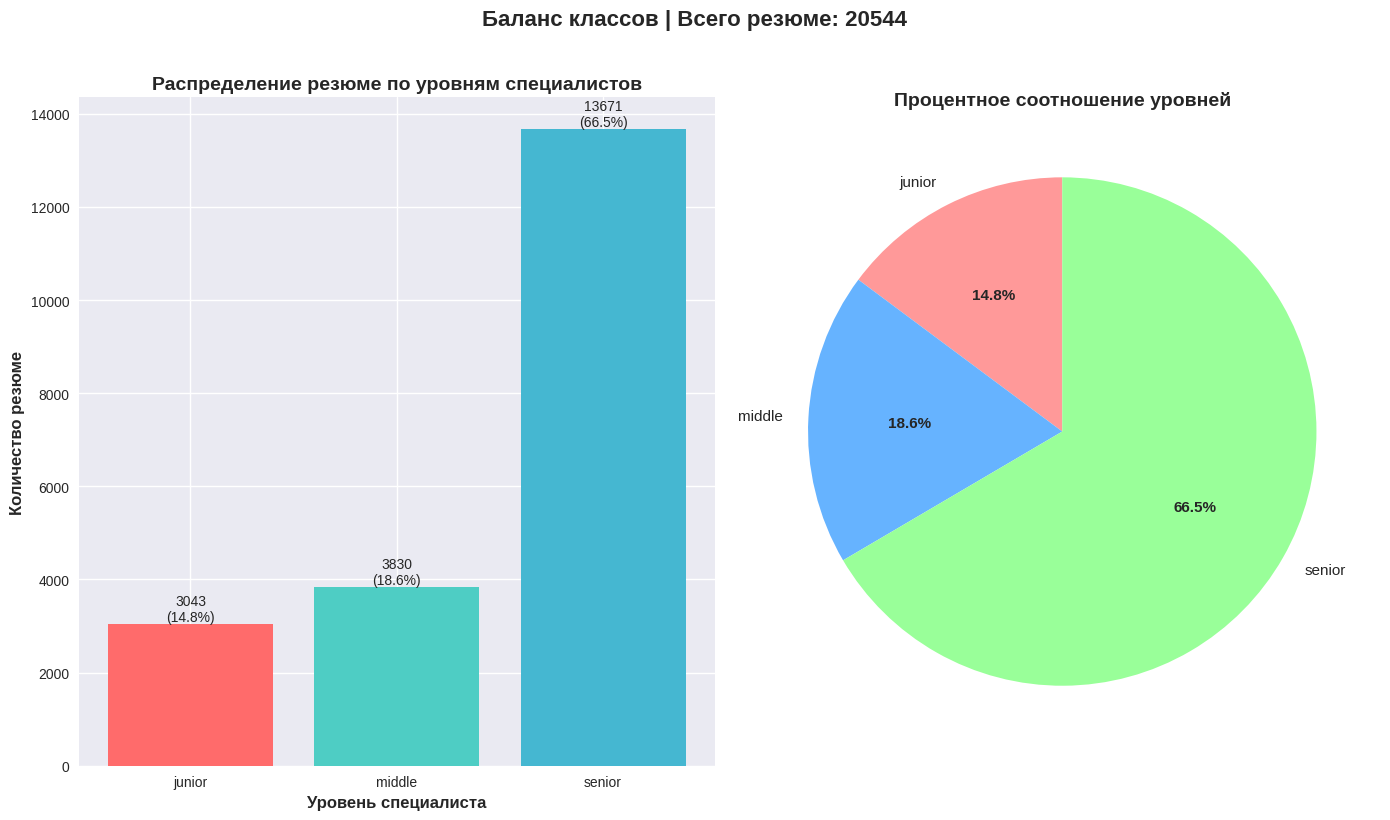

Статистика распределения классов:
junior: {'count': 3043, 'percentage': 14.81}
middle: {'count': 3830, 'percentage': 18.64}
senior: {'count': 13671, 'percentage': 66.54}

Всего образцов: 20544
Коэффициент дисбаланса: 4.49


In [28]:
stats = plot_class_distribution(
    y_data_path='y_data.npy',
    figsize=(14, 8)
)
print("Статистика распределения классов:")
for key, value in stats.items():
    if key not in ['total_samples', 'imbalance_ratio']:
        print(f"{key}: {value}")
print(f"\nВсего образцов: {stats['total_samples']}")
print(f"Коэффициент дисбаланса: {stats['imbalance_ratio']}")

Обучение модели классификации и анализ результатов

Размерность данных: X.shape = (20544, 60), y.shape = (20544,)
Количество признаков: 60

Распределение классов:
  junior: 3043 образцов (14.8%)
  middle: 3830 образцов (18.6%)
  senior: 13671 образцов (66.5%)

Размер train: 14380, размер test: 6164

ОЦЕНКА МОДЕЛЕЙ (кросс-валидация, 5 фолдов)
  Средняя точность кросс-валидации: 0.992 (±0.002)
  Точность на тестовых данных: 0.994

ОТЧЕТ О КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

      junior       0.98      1.00      0.99       913
      middle       0.99      0.98      0.98      1149
      senior       1.00      1.00      1.00      4102

    accuracy                           0.99      6164
   macro avg       0.99      0.99      0.99      6164
weighted avg       0.99      0.99      0.99      6164


МАТРИЦА ОШИБОК


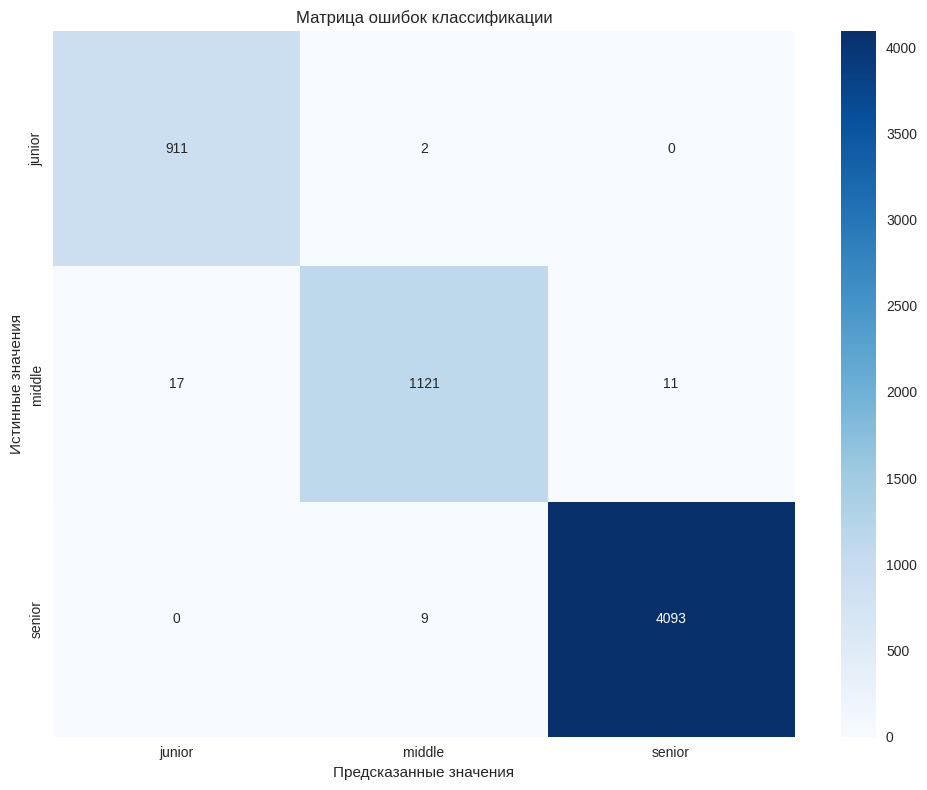


АНАЛИЗ ОШИБОК ПО КЛАССАМ

Класс junior:
  Правильно классифицировано: 911/913 (99.8%)
  Чаще всего путают с: middle (2 случаев)

Класс middle:
  Правильно классифицировано: 1121/1149 (97.6%)
  Чаще всего путают с: junior (17 случаев)

Класс senior:
  Правильно классифицировано: 4093/4102 (99.8%)
  Чаще всего путают с: middle (9 случаев)

Точность baseline (всегда предсказываем 'senior'): 0.665
Улучшение над baseline: 0.328


In [29]:
X, y = load_data()

unique_classes, class_counts = analyze_class_distribution(y)

X_train, X_test, y_train, y_test, scaler = prepare_data(X, y)

model, accuracy, cv_scores = train_and_evaluate_model(X_train, y_train, X_test, y_test)

y_pred, report = generate_classification_report(model, X_test, y_test, unique_classes)

cm = plot_confusion_matrix(y_test, y_pred, unique_classes)

analyze_class_errors(y_test, y_pred, unique_classes)

baseline_accuracy, most_common_class = calculate_baseline(y_test, class_counts, unique_classes)
print(f"Улучшение над baseline: {accuracy - baseline_accuracy:.3f}")